In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import requests
import io

In [32]:
url = 'https://en.wikipedia.org/wiki/NIFTY_500#Constituents'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

response = requests.get(url, headers=headers)

html_content = io.StringIO(response.text)
tables = pd.read_html(html_content)

nifty500_df = tables[4]

In [33]:
header = nifty500_df.iloc[0]
nifty500_df = nifty500_df[1:]
nifty500_df.columns = header
nifty500_df = nifty500_df.reset_index(drop=True)

In [35]:
nifty500_df['Industry'].value_counts()

,count
Industry,
Financial Services,92
Capital Goods,61
Healthcare,46
Chemicals,34
Automobile and Auto Components,33
Fast Moving Consumer Goods,31
Information Technology,25
Consumer Durables,25
Consumer Services,25


In [36]:
nifty500_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Sl.No         500 non-null    object
 1   Company Name  500 non-null    object
 2   Industry      500 non-null    object
 3   Symbol        500 non-null    object
 4   Series        500 non-null    object
 5   ISIN Code     500 non-null    object
dtypes: object(6)
memory usage: 23.6+ KB


In [37]:
tickers = nifty500_df['Symbol'].astype('str') + '.NS'
ticker_list = tickers.tolist()

In [38]:
raw_data = yf.download(ticker_list, period='5y', interval='1d')

/tmp/ipykernel_72395/3014736257.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(ticker_list, period='5y', interval='1d')
[*********************100%***********************]  500 of 500 completed
ERROR:yfinance:
6 Failed downloads:
ERROR:yfinance:['GMRINFRASTRUCT.NS', 'SUVENPHAR.NS', 'SWANENERGY.NS', 'TATAMOTORS.NS', 'PEL.NS', 'ISEC.NS']: YFPricesMissingError('possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")')


In [39]:
closing_prices = raw_data['Close']

In [40]:
pd.set_option('display.max_rows', None)
nan_counts = closing_prices.isna().sum()

In [41]:
nan_counts[nan_counts > 1].count()

np.int64(70)

In [43]:
mask = closing_prices.isna().sum() <= 1
filtered_df = closing_prices.loc[:, mask]
filtered_df = filtered_df.ffill()
filtered_df.isna().sum().sum()

np.int64(0)

In [44]:
log_returns = np.log(filtered_df/filtered_df.shift(1)).dropna()

In [45]:
log_returns.describe()

Ticker,360ONE.NS,3MINDIA.NS,AARTIIND.NS,AAVAS.NS,ABB.NS,ABBOTINDIA.NS,ABCAPITAL.NS,ABFRL.NS,ABREL.NS,ACC.NS,...,WELCORP.NS,WELSPUNLIV.NS,WESTLIFE.NS,WHIRLPOOL.NS,WIPRO.NS,YESBANK.NS,ZEEL.NS,ZENSARTECH.NS,ZFCVINDIA.NS,ZYDUSLIFE.NS
count,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,...,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000
mean,0.001101,0.000228,-0.000364,-0.000451,0.001359,0.000494,0.000893,-0.000853,0.000899,-0.000195,...,0.001591,0.000386,0.000120,-0.000761,0.000020,0.000225,-0.000598,0.000642,0.000706,0.000519
std,0.023205,0.017734,0.021965,0.019991,0.020316,0.014676,0.021423,0.038600,0.026281,0.017861,...,0.027898,0.029133,0.020284,0.020089,0.016268,0.024102,0.031557,0.025325,0.019344,0.015809
min,-0.115613,-0.066112,-0.167822,-0.069056,-0.129643,-0.071765,-0.107759,-1.096384,-0.108606,-0.161787,...,-0.154802,-0.193509,-0.073546,-0.223112,-0.096783,-0.109761,-0.410050,-0.090744,-0.146916,-0.075268
25%,-0.011790,-0.009709,-0.010947,-0.011867,-0.009092,-0.007907,-0.010651,-0.012843,-0.014667,-0.009118,...,-0.014095,-0.015323,-0.012216,-0.009165,-0.008484,-0.010845,-0.015709,-0.013099,-0.009145,-0.008474
50%,-0.000063,-0.001399,-0.000251,-0.000883,0.001604,-0.000403,0.000447,-0.000726,-0.000975,0.000419,...,0.000252,-0.001600,-0.000635,-0.000810,0.000090,-0.000420,-0.001194,-0.000292,-0.000723,0.000448
75%,0.013614,0.008109,0.011166,0.009255,0.011240,0.007615,0.012689,0.011818,0.013433,0.008377,...,0.016085,0.012967,0.010672,0.008616,0.008641,0.009360,0.011805,0.013035,0.009546,0.009482
max,0.138649,0.156057,0.141509,0.096052,0.106401,0.080757,0.101994,0.139074,0.154193,0.096523,...,0.158994,0.180073,0.115858,0.111931,0.085617,0.159759,0.336319,0.178187,0.182322,0.078511


In [46]:
corr_matrix = log_returns.corr()

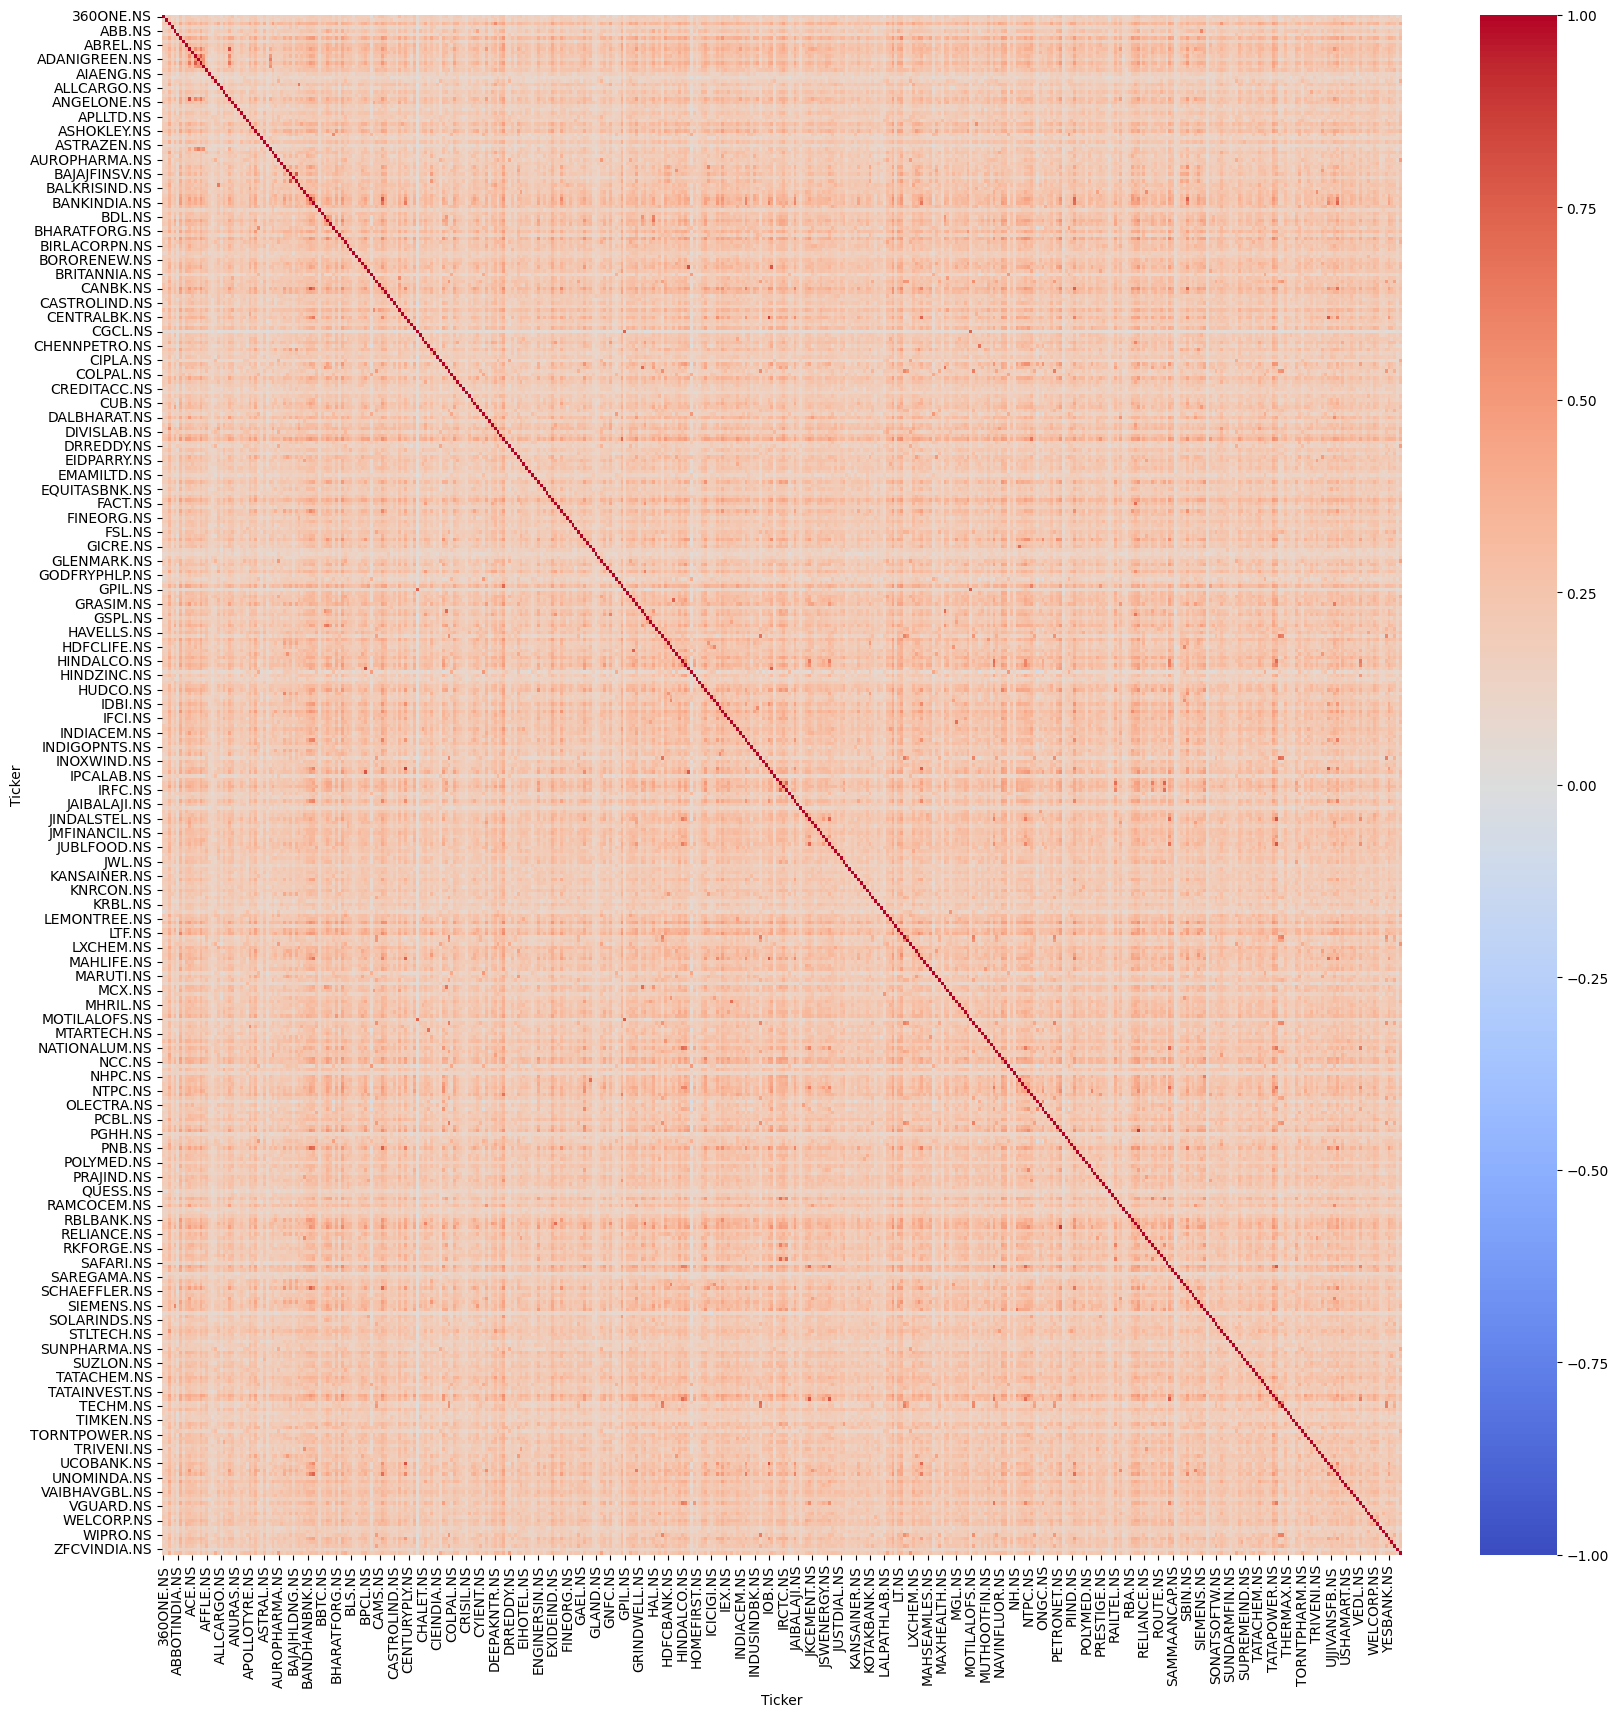

In [47]:
plt.figure(figsize=(20,20))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [48]:
scaled_log_returns = StandardScaler().fit_transform(log_returns)

In [49]:
pca = PCA(n_components=10)

pca.fit(scaled_log_returns)

PCA(n_components=10)

In [50]:
pca.explained_variance_ratio_

array([0.23079268, 0.02337812, 0.01577955, 0.01385844, 0.01132178,
       0.00940769, 0.00857983, 0.00777846, 0.00669602, 0.00630465])

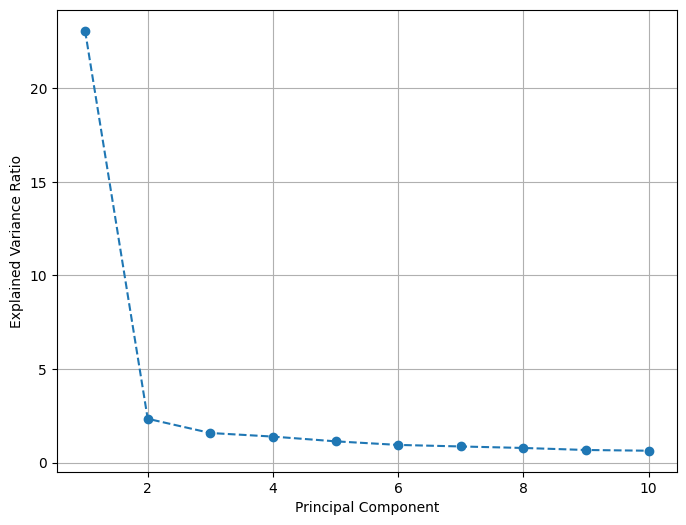

In [52]:
plt.figure(figsize=(8, 6))
plt.plot(range(1,11), pca.explained_variance_ratio_*100, marker='o', linestyle='--')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

In [53]:
industry_map = (
    nifty500_df[['Symbol', 'Industry']].drop_duplicates('Symbol').set_index('Symbol')['Industry']
)

In [54]:
pc1_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[0] * 100
})

pc1_df['Industry'] = pc1_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc1_sorted = pc1_df.sort_values(by='Weight', ascending=False)

display(pc1_sorted.head(20)['Industry'].value_counts())
display(pc1_sorted.tail(20)['Industry'].value_counts())

,count
Industry,
Financial Services,9
Realty,2
Capital Goods,2
Metals & Mining,2
Power,1
Automobile and Auto Components,1
Chemicals,1
Construction,1
Consumer Services,1


,count
Industry,
Healthcare,10
Fast Moving Consumer Goods,5
Financial Services,2
Capital Goods,2
Services,1


In [55]:
# nifty500_df.columns = nifty500_df.columns.str.strip()

pc2_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[1] * 100
})

pc2_df['Industry'] = (pc2_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map))

pc2_sorted = pc2_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc2_sorted.head(20)['Industry'].value_counts())
display(pc2_sorted.tail(20)['Industry'].value_counts())

,count
Industry,
Information Technology,10
Fast Moving Consumer Goods,6
Consumer Durables,1
Chemicals,1
Consumer Services,1
Healthcare,1


,count
Industry,
Financial Services,8
Oil Gas & Consumable Fuels,4
Construction,4
Power,3
Telecommunication,1


In [56]:
pc3_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[2] * 100
})

pc3_df['Industry'] = (pc3_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map))

pc3_sorted = pc3_df.sort_values(by='Weight', ascending=False)

display(pc3_sorted.head(20)['Industry'].value_counts())
display(pc3_sorted.tail(20)['Industry'].value_counts())

,count
Industry,
Financial Services,15
Automobile and Auto Components,2
Construction Materials,2
Capital Goods,1


,count
Industry,
Information Technology,17
Services,2
Healthcare,1


In [57]:
pc4_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[3] * 100
})

pc4_df['Industry'] = (pc4_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map))

pc4_sorted = pc4_df.sort_values(by='Weight', ascending=False)

display(pc4_sorted.head(20)['Industry'].value_counts())
display(pc4_sorted.tail(20)['Industry'].value_counts())

,count
Industry,
Metals & Mining,9
Information Technology,8
Oil Gas & Consumable Fuels,3


,count
Industry,
Fast Moving Consumer Goods,10
Consumer Durables,4
Automobile and Auto Components,3
Textiles,1
Capital Goods,1
Chemicals,1
